# Exploratory Data Analysis — Superstore Sales Dataset

**Dataset Source:** Kaggle — [Sample Superstore](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final) *(synthetic replica)*  
**Author:** Student Project — AI/ML Minor Assignment  
**Institution:** Unilox Academy  

---

## 1 · Introduction & Business Context

The *Superstore Sales* dataset captures retail transaction records across the USA (2021–2023), covering product categories, customer segments, shipping preferences, and financial metrics (sales, profit, discounts).

### Data Dictionary
| Column | Type | Description |
|---|---|---|
| Order_ID | str | Unique order identifier |
| Customer_ID | str | Customer reference |
| Order_Date | datetime | Date order was placed |
| Ship_Mode | str (Ordinal) | Shipping speed tier |
| Customer_Age | int | Age of the customer |
| Segment | str (Ordinal) | Consumer / Corporate / Home Office |
| City / Region | str (Nominal) | Geographic identifiers |
| Category | str (Nominal) | Product category |
| Sub_Category | str (Nominal) | Product sub-category |
| Unit_Price | float | Price per individual unit |
| Quantity | int | Units ordered |
| Discount | float | Fractional discount applied (0–0.5) |
| Sales | float | Total revenue for the order line |
| Profit | float | Net profit for the order line |

### Core Business Questions
1. Which **product category and sub-category** drives the highest revenue and profit?
2. How do **customer segments** differ in spending patterns and profitability?
3. What is the relationship between **discount rates** and profitability?
4. Are there **regional disparities** in sales performance?
5. How does **shipping mode choice** correlate with order value?


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder
import os

sns.set_theme(style="whitegrid",palette="muted")

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

df = pd.read_csv('/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv',
                 encoding='latin-1')

print(f"\nDataset Shape: {df.shape}")
df.head()

/kaggle/input/datasets/vivek468/superstore-dataset-final/Sample - Superstore.csv

Dataset Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

2. Data Cleaning & Integrity Checks

In [40]:
df['Order Date'] =pd.to_datetime(df['Order Date'])
df['Ship Date']=pd.to_datetime(df['Ship Date'])

print("After Fix:")
print(df[['Order Date','Ship Date']].dtypes)
print(df[['Order Date','Ship Date']].head())

After Fix:
Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object
  Order Date  Ship Date
0 2016-11-08 2016-11-11
1 2016-11-08 2016-11-11
2 2016-06-12 2016-06-16
3 2015-10-11 2015-10-18
4 2015-10-11 2015-10-18


In [41]:
missing=df.isnull().sum()
missing_pct =(missing/len(df)*100).round(2)

miss_df=pd.DataFrame({
    'Missing Count': missing,
    '% Missing': missing_pct
})
print("Missing Values Report:")
print(miss_df[miss_df['Missing Count']> 0])

Missing Values Report:
Empty DataFrame
Columns: [Missing Count, % Missing]
Index: []


In [42]:

df['Postal Code']= df['Postal Code'].fillna(0)

for col in df.select_dtypes(include='number').columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(),inplace=True)
        print(f"{col} → filled with median")


for col in df.select_dtypes(include='object').columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"{col}→filled with mode")

print("\nMissing values after handling:",df.isnull().sum().sum())


Missing values after handling: 0


In [43]:
dups = df.duplicated().sum()
print(f"Duplicate rows found:{dups}")

df.drop_duplicates(inplace=True)
df.reset_index(drop=True,inplace=True)

print(f"Dataset shape after removing duplicates:{df.shape}")

Duplicate rows found:0
Dataset shape after removing duplicates:(9994, 21)


 3. Outlier Analysis

Skewness of Numerical Features:
Sales       12.97
Quantity     1.28
Discount     1.68
Profit       7.56
dtype: float64


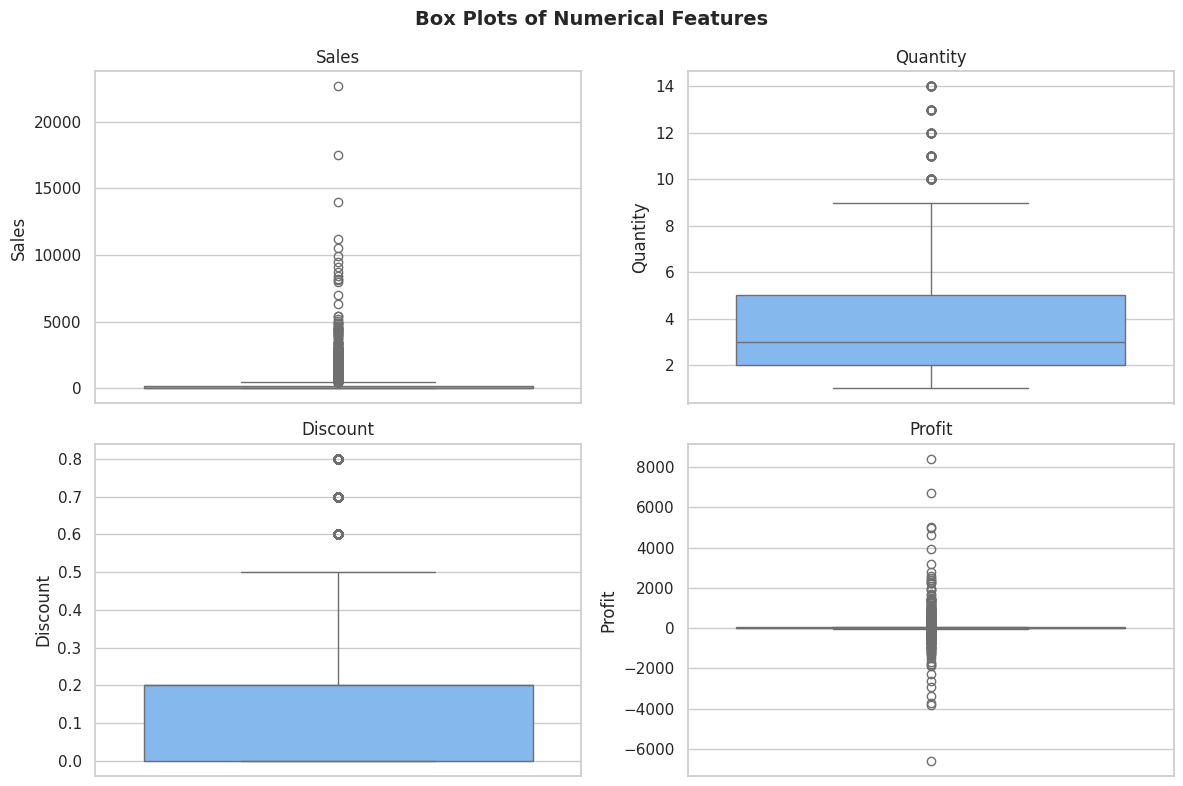

In [44]:
num_cols = ['Sales','Quantity','Discount','Profit']

print("Skewness of Numerical Features:")
print(df[num_cols].skew().round(2))

fig,axes =plt.subplots(2, 2,figsize=(12,8))

for ax,col in zip(axes.flat,num_cols):
    sns.boxplot(y=df[col],ax=ax,color="#74b9ff")
    ax.set_title(col)

plt.suptitle("Box Plots of Numerical Features",fontsize=14,fontweight="bold")
plt.tight_layout()
plt.show()

In [45]:

print(f"{'Feature':<12}{'Outliers':>10} {'Lower Fence':>13} {'Upper Fence':>13}")
print("-" *55)

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3=df[col].quantile(0.75)
    IQR = Q3-Q1

    lower = Q1-1.5 * IQR
    upper = Q3+1.5 *IQR

    outliers= df[(df[col]<lower)|(df[col]>upper)]
    n = len(outliers)

    print(f"{col:<12}{n:>10} {lower:>13.2f} {upper:>13.2f}")

Feature       Outliers   Lower Fence   Upper Fence
-------------------------------------------------------
Sales             1167       -271.71        498.93
Quantity           170         -2.50          9.50
Discount           856         -0.30          0.50
Profit            1881        -39.72         70.82


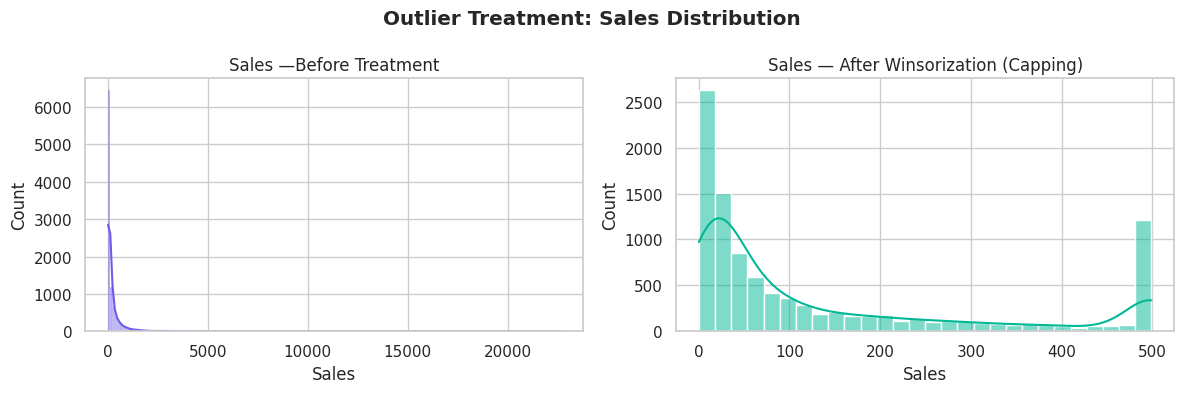

In [46]:

fig,axes=plt.subplots(1,2,figsize=(12, 4))

sns.histplot(df['Sales'],kde=True,ax=axes[0],color="#6c5ce7")
axes[0].set_title("Sales —Before Treatment")

for col in ['Sales','Profit']:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3-Q1
    df[col]=df[col].clip(Q1 -1.5* IQR, Q3+ 1.5 *IQR)


df['Sales_Log'] =np.log1p(df['Sales'])

sns.histplot(df['Sales'],kde=True,ax=axes[1],color="#00b894")
axes[1].set_title("Sales — After Winsorization (Capping)")

plt.suptitle("Outlier Treatment: Sales Distribution",fontweight="bold")
plt.tight_layout()
plt.show()

4. Bivariate & Multivariate Exploration

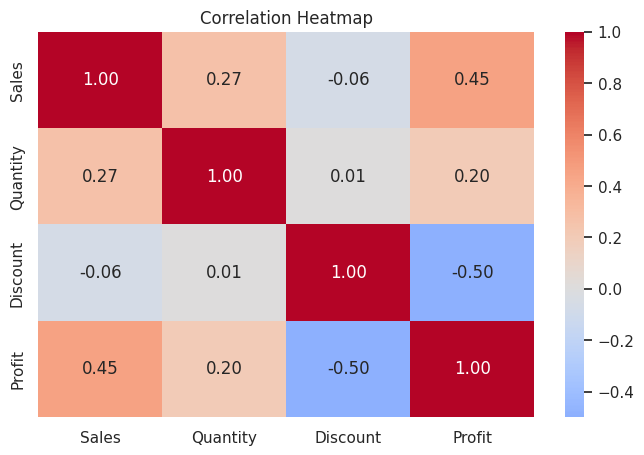

In [47]:
plt.figure(figsize=(8,5))
sns.heatmap(df[['Sales','Quantity','Discount','Profit']].corr(),
            annot=True,fmt=".2f",cmap="coolwarm",center=0)
plt.title("Correlation Heatmap")
plt.show()

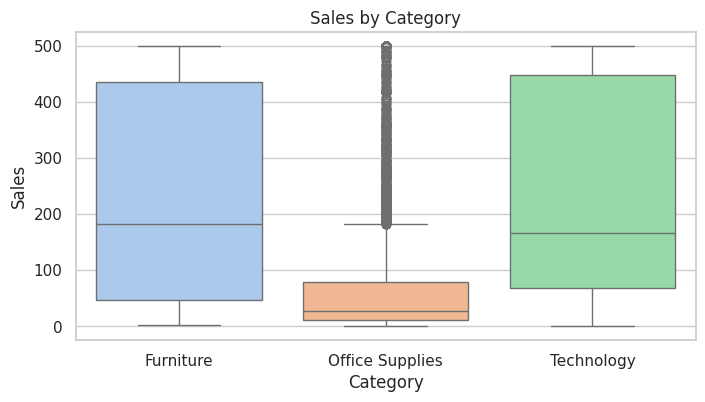

In [48]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df,x='Category',y='Sales',palette='pastel')
plt.title("Sales by Category")
plt.show()

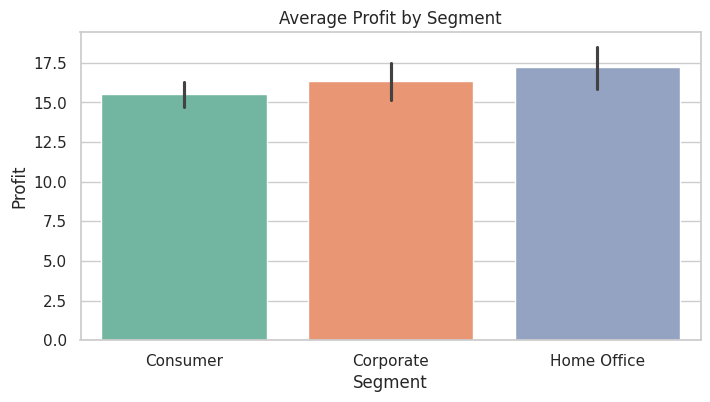

In [49]:

plt.figure(figsize=(8,4))
sns.barplot(data=df,x='Segment',y='Profit',palette='Set2')
plt.title("Average Profit by Segment")
plt.show()

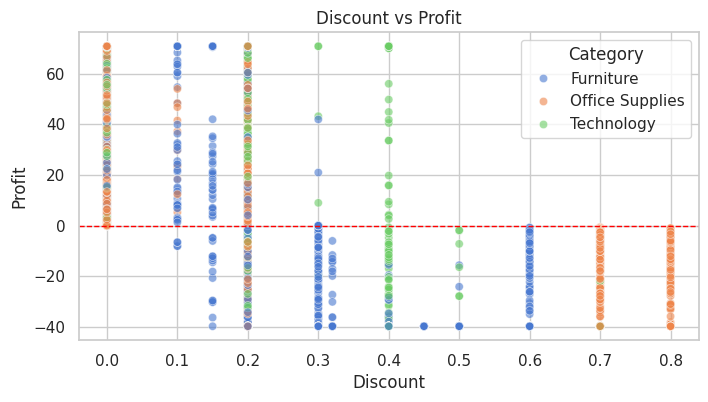

In [50]:

plt.figure(figsize=(8,4))
sns.scatterplot(data=df,x='Discount',y='Profit', 
                hue='Category',alpha=0.6)
plt.axhline(0,color='red',ls='--',lw=1)
plt.title("Discount vs Profit")
plt.show()

5.  Feature Engineering & Encoding Preparation

In [51]:

df['Ship_Days']=(df['Ship Date']-df['Order Date']).dt.days
df['Profit_Margin']= (df['Profit']/df['Sales']).round(4)
df['Is_Discounted']= (df['Discount']>0).astype(int)

print(df[['Ship_Days','Profit_Margin','Is_Discounted']].head())

   Ship_Days  Profit_Margin  Is_Discounted
0          3         0.1600              0
1          3         0.1419              0
2          4         0.4700              0
3          7        -0.0796              1
4          7         0.1125              1


In [52]:

seg_map ={'Consumer':1,'Corporate':2,'Home Office':3}
ship_map = {'Standard Class':1,'Second Class':2, 
            'First Class':3, 'Same Day':4}

df['Segment_Ordinal']=df['Segment'].map(seg_map)
df['ShipMode_Ordinal'] =df['Ship Mode'].map(ship_map)

print(df[['Segment','Segment_Ordinal','Ship Mode','ShipMode_Ordinal']].drop_duplicates())

         Segment  Segment_Ordinal       Ship Mode  ShipMode_Ordinal
0       Consumer                1    Second Class                 2
2      Corporate                2    Second Class                 2
3       Consumer                1  Standard Class                 1
14   Home Office                3  Standard Class                 1
21     Corporate                2  Standard Class                 1
34   Home Office                3    Second Class                 2
35     Corporate                2     First Class                 3
55      Consumer                1     First Class                 3
84   Home Office                3     First Class                 3
366    Corporate                2        Same Day                 4
657  Home Office                3        Same Day                 4
664     Consumer                1        Same Day                 4


In [53]:

df_encoded=pd.get_dummies(df,columns=['Category','Region'], 
                             drop_first=False, dtype=int)

ohe_cols=[c for c in df_encoded.columns 
            if c.startswith('Category_') or c.startswith('Region_')]
print(df_encoded[ohe_cols].head())

   Category_Furniture  Category_Office Supplies  Category_Technology  \
0                   1                         0                    0   
1                   1                         0                    0   
2                   0                         1                    0   
3                   1                         0                    0   
4                   0                         1                    0   

   Region_Central  Region_East  Region_South  Region_West  
0               0            0             1            0  
1               0            0             1            0  
2               0            0             0            1  
3               0            0             1            0  
4               0            0             1            0  
